# Jev vs GPT on Banking77 intent classification

Head-to-head on the 77-intent banking dataset already in this repo
(`prompt_optimisation_gepa_ace/banking_data_split/`), chosen for two reasons: it is
genuinely hard (77 fine-grained, confusable intents), and **it already has published
baselines from Claude models on this exact test split**, so there is something to anchor to.

| Prior result (same 201-row test set) | Model | Accuracy |
| --- | --- | --- |
| Chain-of-thought | Claude Haiku 4.5 | 79.7% |
| GEPA baseline | Claude Haiku 4.5 | 75.6% |
| GEPA optimised | Claude Haiku 4.5 | 76.1% |
| ACE | Claude Haiku 4.5 | 71.6% |

Sources: `gepa_example_banking.ipynb` cell 23 and `ace/banking/results/*/summary.json`.

### Keeping the comparison honest

The scoring harness lives in `bench_utils.py` and every model goes through it, so the metric and
the label normalisation are literally the same code. Beyond that:

- **Same prompt, same labels.** Every model gets the identical instruction string and the bare
  list of label names. Jev gets them as `choice` criteria with `null` descriptions; the GPT models
  get them as a JSON-schema string `enum`. Nobody gets hand-written label descriptions.
- **Everyone is format-constrained.** No model can return an out-of-vocabulary answer, so any gap
  reflects judgement rather than an inability to follow an output format.
- **Everyone is zero-shot.** No model sees the train or val split.

That makes the chain-of-thought baseline (79.7%) the fair anchor: GEPA and ACE consumed the
train/val splits to optimise their prompts, so comparing a zero-shot call against them would
flatter the zero-shot model.

One caveat no amount of harness discipline fixes: the prior numbers came from a different
framework (DSPy, exact-match lowercase). Treat them as a sanity anchor, not as a figure
directly commensurable with this run.

## 1. Setup

In [1]:
# !pip install -r requirements.txt

In [2]:
import collections
import itertools
import os

import matplotlib.pyplot as plt
import pandas as pd

import bench_utils as bu

config = bu.load_config()
print("keys loaded:", [k for k in config if k.endswith("_API_KEY")])

keys loaded: ['OPENAI_API_KEY', 'GOOGLE_API_KEY', 'TAVILY_API_KEY', 'LAMINI_API_KEY', 'ANTHROPIC_API_KEY', 'WANDB_API_KEY', 'JEV_API_KEY']


## 2. Data

The full 201-row test split, so the numbers line up with the prior baselines. The label set is
the union of all three splits - all 77 intents are offered as options even though only 74 of
them appear among the test rows.

In [3]:
DATASET = "banking77"
DATA = "../prompt_optimisation_gepa_ace/banking_data_split/"

train_df = pd.read_csv(DATA + "train.csv")
val_df = pd.read_csv(DATA + "val.csv")
test_df = pd.read_csv(DATA + "test.csv")

LABELS = sorted(set(train_df["category"]) | set(val_df["category"]) | set(test_df["category"]))

sample_df = test_df.reset_index(drop=True)
sample_df["record_id"] = sample_df.index.astype(str)
sample_df = sample_df.rename(columns={"category": "gold"})

print(f"rows           : {len(sample_df)}")
print(f"labels offered : {len(LABELS)}")
print(f"labels present : {sample_df['gold'].nunique()}")
sample_df[["record_id", "text", "gold"]].head()

rows           : 201
labels offered : 77
labels present : 74


,record_id,text,gold
0,0,Is it possible for me to change my PIN number?,change_pin
1,1,How long does a transfer from a UK account tak...,balance_not_updated_after_bank_transfer
2,2,Why am I getting declines when trying to make ...,declined_transfer
3,3,What is the $1 transaction on my account?,extra_charge_on_statement
4,4,How much does top up fees cost?,top_up_by_card_charge


## 3. The models

`INSTRUCTIONS` is shared verbatim - it is the system prompt for the GPT models and the
`instructions` field of the Jev `choice` question.

In [4]:
INSTRUCTIONS = (
    "Classify this banking customer support message into its intent category. "
    "Choose the single category that best matches what the customer is asking about."
)

OPENAI_MODELS = [
    "gpt-5.6-luna",
    "gpt-5.6-terra",
]

jev = bu.JevClassifier(LABELS, INSTRUCTIONS, name="jev-latest")
gpt_models = {
    name: bu.OpenAIClassifier(LABELS, INSTRUCTIONS, model=name, name=name)
    for name in OPENAI_MODELS
}

records = sample_df[["record_id", "text", "gold"]].to_dict(orient="records")
gold_by_id = {r["record_id"]: r["gold"] for r in records}
print(f"{len(records)} records x {1 + len(gpt_models)} models")

201 records x 3 models


## 4. Run

Results are cached to `.cache/` per model and record, so re-running costs nothing for rows
already done and a partially-failed run resumes instead of re-spending. Failed rows are
deliberately *not* cached, so re-running a cell is also how you retry them.

In [5]:
raw_results = {}

raw_results[jev.name] = bu.run_benchmark(
    records, jev, dataset=DATASET, text_key="text", max_workers=8
)

[jev-latest] 201 records | cached 201 | to run 0


The GPT models run in a separate cell so a failure on that side leaves the Jev results intact.

In [6]:
for name, classifier in gpt_models.items():
    raw_results[name] = bu.run_benchmark(
        records, classifier, dataset=DATASET, text_key="text", max_workers=8
    )

[gpt-5.6-luna] 201 records | cached 0 | to run 201


  ... 25/201


  ... 50/201


  ... 75/201


  ... 100/201


...

  ... 100/201


  ... 125/201


  ... 150/201


  ... 175/201


  ... 200/201
  201 failed - e.g. RateLimitError: Error code: 429 - {'error': {'message': 'You have no credits remaining. Add credits to continue using th
  rerun this cell to retry only the failures


## 5. Scoring

In [7]:
scored_by_model = {}
for name, rows in raw_results.items():
    scored = bu.score_predictions(rows, gold_by_id)
    if any(r["correct"] is not None for r in scored):
        scored_by_model[name] = scored
    else:
        print(f"{name}: no usable answers - excluded from the comparison")

summary = pd.DataFrame(bu.summarise(scored_by_model)) if scored_by_model else pd.DataFrame()
summary

gpt-5.6-luna: no usable answers - excluded from the comparison
gpt-5.6-terra: no usable answers - excluded from the comparison


,model,n,answered,accuracy,errors,median_latency_s,input_tokens,output_tokens
0,jev-latest,201,201,0.8109,0,0.66,209626,166485


### Accuracy with a confidence interval

The interval is the honest version of the headline number: at these sample sizes the sampling
error is usually wider than the gap people try to read between two models.

In [8]:
rows = []
for model, scored in scored_by_model.items():
    answered = [r for r in scored if r["correct"] is not None]
    n_correct = sum(1 for r in answered if r["correct"])
    low, high = bu.wilson_interval(n_correct, len(answered))
    rows.append(
        {
            "model": model,
            "answered": len(answered),
            "correct": n_correct,
            "accuracy": round(n_correct / len(answered), 4) if answered else None,
            "ci_low": low,
            "ci_high": high,
        }
    )

accuracy_df = pd.DataFrame(rows).sort_values("accuracy", ascending=False).reset_index(drop=True)
accuracy_df

,model,answered,correct,accuracy,ci_low,ci_high
0,jev-latest,201,163,0.8109,0.7512,0.8591


### Are the differences real?

Every model answered the same items, so McNemar's paired test is the right question: among the
items where two models disagreed, was the split lopsided enough to be more than chance?

Only items that *both* models actually answered are counted - an API failure is not a wrong
answer, and counting outages as losses would manufacture significance out of downtime.

In [9]:
pairs = list(itertools.combinations(scored_by_model, 2))
if not pairs:
    print("Need at least two models with results before a paired test means anything.")

pair_rows = []
for model_a, model_b in pairs:
    a_only, b_only, p_value, n_shared = bu.mcnemar(
        scored_by_model[model_a], scored_by_model[model_b]
    )
    pair_rows.append(
        {
            "model_a": model_a,
            "model_b": model_b,
            "shared_items": n_shared,
            "a_right_b_wrong": a_only,
            "b_right_a_wrong": b_only,
            "p_value": p_value,
            "verdict": (
                "distinguishable" if p_value < 0.05 else "not distinguishable"
            ),
        }
    )

pd.DataFrame(pair_rows) if pair_rows else None

Need at least two models with results before a paired test means anything.


## 6. Against the prior baselines

The published numbers are converted back to counts out of 201 so they get the same confidence
interval treatment as the live runs.

In [10]:
N_TEST = 201
BASELINES = {
    "Claude Haiku 4.5\n(chain-of-thought)": 0.797,
    "Claude Haiku 4.5\n(GEPA optimised)": 0.761,
    "Claude Haiku 4.5\n(ACE)": 0.716,
}

comparison = []
for model, scored in scored_by_model.items():
    answered = [r for r in scored if r["correct"] is not None]
    n_correct = sum(1 for r in answered if r["correct"])
    low, high = bu.wilson_interval(n_correct, len(answered))
    comparison.append(
        {"label": model, "accuracy": n_correct / len(answered), "ci_low": low,
         "ci_high": high, "kind": "this run"}
    )

for label, accuracy in BASELINES.items():
    n_correct = round(accuracy * N_TEST)
    low, high = bu.wilson_interval(n_correct, N_TEST)
    comparison.append(
        {"label": label, "accuracy": accuracy, "ci_low": low, "ci_high": high,
         "kind": "prior work"}
    )

comparison_df = (
    pd.DataFrame(comparison).sort_values("accuracy", ascending=False).reset_index(drop=True)
)
comparison_df

,label,accuracy,ci_low,ci_high,kind
0,jev-latest,0.810945,0.7512,0.8591,this run
1,Claude Haiku 4.5\n(chain-of-thought),0.797000,0.7350,0.8459,prior work
2,Claude Haiku 4.5\n(GEPA optimised),0.761000,0.6977,0.8149,prior work
3,Claude Haiku 4.5\n(ACE),0.716000,0.6505,0.7742,prior work


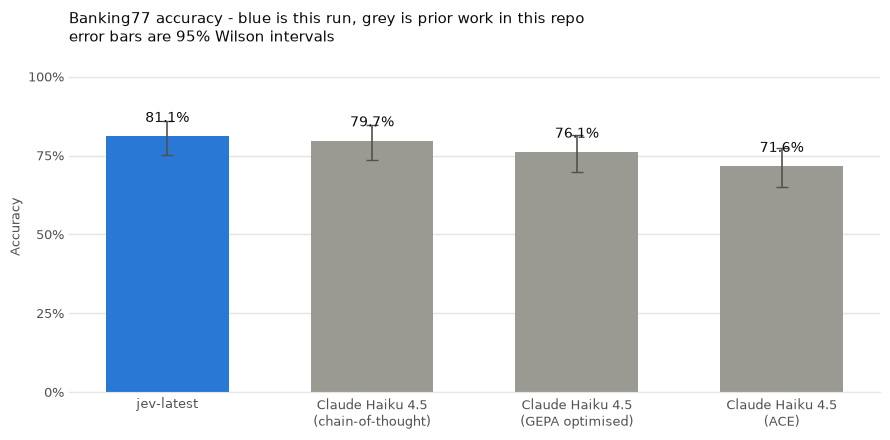

In [11]:
if comparison_df.empty:
    print("Nothing to plot yet.")
else:
    fig, ax = plt.subplots(figsize=(9, 4.5))

    colors = {"this run": bu.SERIES[0], "prior work": "#9a9992"}
    bar_colors = [colors.get(k, bu.SERIES[0]) for k in comparison_df["kind"]]

    x = range(len(comparison_df))
    lower = comparison_df["accuracy"] - comparison_df["ci_low"]
    upper = comparison_df["ci_high"] - comparison_df["accuracy"]

    ax.bar(
        x, comparison_df["accuracy"], color=bar_colors, width=0.6,
        yerr=[lower, upper], capsize=4,
        error_kw={"ecolor": "#52514e", "elinewidth": 1.2},
    )

    for xi, value in zip(x, comparison_df["accuracy"]):
        ax.text(
            xi, value + 0.035, f"{value:.1%}", ha="center", va="bottom",
            color=bu.TEXT_PRIMARY, fontsize=10,
        )

    ax.set_xticks(list(x))
    ax.set_xticklabels(comparison_df["label"], fontsize=8)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Accuracy", color=bu.TEXT_SECONDARY, fontsize=9)
    ax.yaxis.grid(True, color=bu.GRID, linewidth=1)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(["0%", "25%", "50%", "75%", "100%"])
    ax.set_title(
    "Banking77 accuracy - blue is this run, grey is prior work in this repo\n"
    "error bars are 95% Wilson intervals",
        color=bu.TEXT_PRIMARY, fontsize=11, loc="left", pad=14,
    )
    bu.style_axis(ax)
    fig.tight_layout()
    plt.show()

## 7. Where the errors are

With 77 intents the interesting question is not the headline number but *which* pairs get
confused: a model that mixes up `declined_transfer` and `declined_card_payment` is failing
differently from one that picks something unrelated.

In [12]:
for model, scored in scored_by_model.items():
    mistakes = [r for r in scored if r["correct"] is False]
    print(f"\n=== {model}: {len(mistakes)} mistakes ===")
    confusions = collections.Counter((r["gold"], r["label"]) for r in mistakes)
    for (gold, predicted), count in confusions.most_common(12):
        print(f"  {count}x  {gold}  ->  {predicted}")


=== jev-latest: 38 mistakes ===
  3x  reverted_card_payment?  ->  declined_card_payment
  3x  card_about_to_expire  ->  order_physical_card
  2x  balance_not_updated_after_bank_transfer  ->  transfer_timing
  2x  extra_charge_on_statement  ->  pending_card_payment
  2x  disposable_card_limits  ->  get_disposable_virtual_card
  1x  declined_transfer  ->  declined_card_payment
  1x  balance_not_updated_after_cheque_or_cash_deposit  ->  balance_not_updated_after_bank_transfer
  1x  automatic_top_up  ->  top_up_limits
  1x  cash_withdrawal_not_recognised  ->  receiving_money
  1x  reverted_card_payment?  ->  transaction_charged_twice
  1x  country_support  ->  get_physical_card
  1x  pending_cash_withdrawal  ->  pending_transfer


### Does confidence predict correctness?

This is the property that makes a typed answer more useful than a parsed string. If accuracy
climbs with confidence, the confidence is doing real work and you can route the low-confidence
tail to a human instead of trusting every verdict equally.

In [13]:
calibration_rows = []
for model, scored in scored_by_model.items():
    have_conf = [
        r for r in scored if r.get("confidence") is not None and r["correct"] is not None
    ]
    if not have_conf:
        print(f"{model}: no confidence values available")
        continue
    frame = pd.DataFrame(have_conf)
    frame["bucket"] = pd.cut(
        frame["confidence"], [0, 0.5, 0.7, 0.9, 1.0], include_lowest=True,
        labels=["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"],
    )
    grouped = frame.groupby("bucket", observed=False)["correct"].agg(["mean", "size"])
    grouped["model"] = model
    calibration_rows.append(grouped.reset_index())

calibration = pd.concat(calibration_rows) if calibration_rows else pd.DataFrame()
calibration

,bucket,mean,size,model
0,<=0.5,0.250000,12,jev-latest
1,0.5-0.7,0.560000,25,jev-latest
2,0.7-0.9,0.760870,46,jev-latest
3,0.9-1.0,0.940678,118,jev-latest


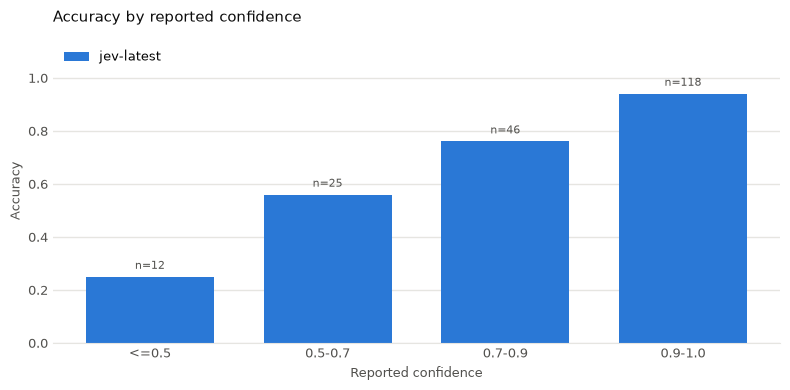

In [14]:
if calibration.empty:
    print("No confidence data to plot yet.")
else:
    fig, ax = plt.subplots(figsize=(8, 4))
    buckets = ["<=0.5", "0.5-0.7", "0.7-0.9", "0.9-1.0"]
    n_models = calibration["model"].nunique()
    width = 0.8 / max(1, n_models)

    for i, (model, group) in enumerate(calibration.groupby("model")):
        group = group.set_index("bucket").reindex(buckets).reset_index()
        offsets = [b + i * width for b in range(len(buckets))]
        ax.bar(
            offsets, group["mean"].fillna(0), width=width * 0.9,
            color=bu.SERIES[i % len(bu.SERIES)], label=model,
        )
        for xi, (value, size) in enumerate(zip(group["mean"], group["size"])):
            if pd.notna(value) and size:
                ax.text(
                    offsets[xi], value + 0.02, f"n={int(size)}",
                    ha="center", va="bottom", color=bu.TEXT_SECONDARY, fontsize=8,
                )

    ax.set_xticks([b + width * (n_models - 1) / 2 for b in range(len(buckets))])
    ax.set_xticklabels(buckets)
    ax.set_xlabel("Reported confidence", color=bu.TEXT_SECONDARY, fontsize=9)
    ax.set_ylabel("Accuracy", color=bu.TEXT_SECONDARY, fontsize=9)
    ax.set_ylim(0, 1.15)
    ax.yaxis.grid(True, color=bu.GRID, linewidth=1)
    ax.legend(frameon=False, fontsize=9, loc="upper left")
    ax.set_title(
        "Accuracy by reported confidence", color=bu.TEXT_PRIMARY,
        fontsize=11, loc="left", pad=12,
    )
    bu.style_axis(ax)
    fig.tight_layout()
    plt.show()

## 8. Save the per-row results

Committed so the comparison is inspectable without re-running (and re-paying for) anything.

In [15]:
os.makedirs("results", exist_ok=True)

if scored_by_model:
    combined = pd.concat(
        [pd.DataFrame(rows).assign(model=model) for model, rows in scored_by_model.items()]
    )
    combined = combined.merge(sample_df[["record_id", "text"]], on="record_id", how="left")
    combined.to_csv(f"results/{DATASET}_predictions.csv", index=False)
    print(f"wrote results/{DATASET}_predictions.csv ({len(combined)} rows)")

if not summary.empty:
    summary.to_csv(f"results/{DATASET}_summary.csv", index=False)
    print(f"wrote results/{DATASET}_summary.csv")

wrote results/banking77_predictions.csv (201 rows)
wrote results/banking77_summary.csv


## Notes

- **Cost shape differs between the APIs.** Jev returns a probability over every option, so its
  output-token count scales with the size of the label set. A GPT model under a JSON-schema enum
  emits only the chosen label. Compare cost per correct answer, not raw token counts.
- **The confidences are not the same quantity.** Jev reports a calibrated `confidence`; the GPT
  figure is derived from token logprobs. Compare them as rankings (does higher mean more often
  right?), not as absolute numbers on a shared scale.
- **Some models refuse logprobs.** `gpt-5-mini` returns a 403 for them; the harness drops
  logprobs and retries, leaving confidence as `None` rather than failing the row.
- **A single split flatters whoever got lucky.** 201 items give a ~6-point interval, which
  cannot separate models that are genuinely a couple of points apart. When intervals overlap,
  the honest conclusion is "not distinguishable" - and the fix is more items, not a bolder
  claim.